## 🚀 Quick Start

**Concepts:** [Graph representations](../problem.md#graph-representations) · [Optimization approaches](../routers.md#optimization-approaches) **Network/Router API:** [🚀 Quick Start](hi00_quickstart.ipynb)

Three ways to obtain a network, in increasing order of runtime and quality. The routers are described in [Routers](../routers.md); the graphs passed between the calls (`L`, `P`, `A`, `S`, `G`) are described in [Graph representations](../problem.md#graph-representations).

In [1]:
from optiwindnet.importer import load_repository
from optiwindnet.interarraylib import G_from_S
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.pathfinding import PathFinder
from optiwindnet.svg import svgplot

In [2]:
locations = load_repository()

### Quickest (sub-second)

In [3]:
from optiwindnet.heuristics import constructor

In [4]:
L = locations.doggerA

In [5]:
%%timeit
P, A = make_planar_embedding(L)

8.2 ms ± 373 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [6]:
P, A = make_planar_embedding(L)

In [7]:
%%timeit
S_pre = constructor(A, capacity=8)

6.94 ms ± 172 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [8]:
S_pre = constructor(A, capacity=8)

In [9]:
%%timeit
G_tentative = G_from_S(S_pre, A)
G_pre = PathFinder(G_tentative, planar=P, A=A).create_detours()

24.8 ms ± 1.2 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [10]:
G_tentative = G_from_S(S_pre, A)
G_pre = PathFinder(G_tentative, planar=P, A=A).create_detours()

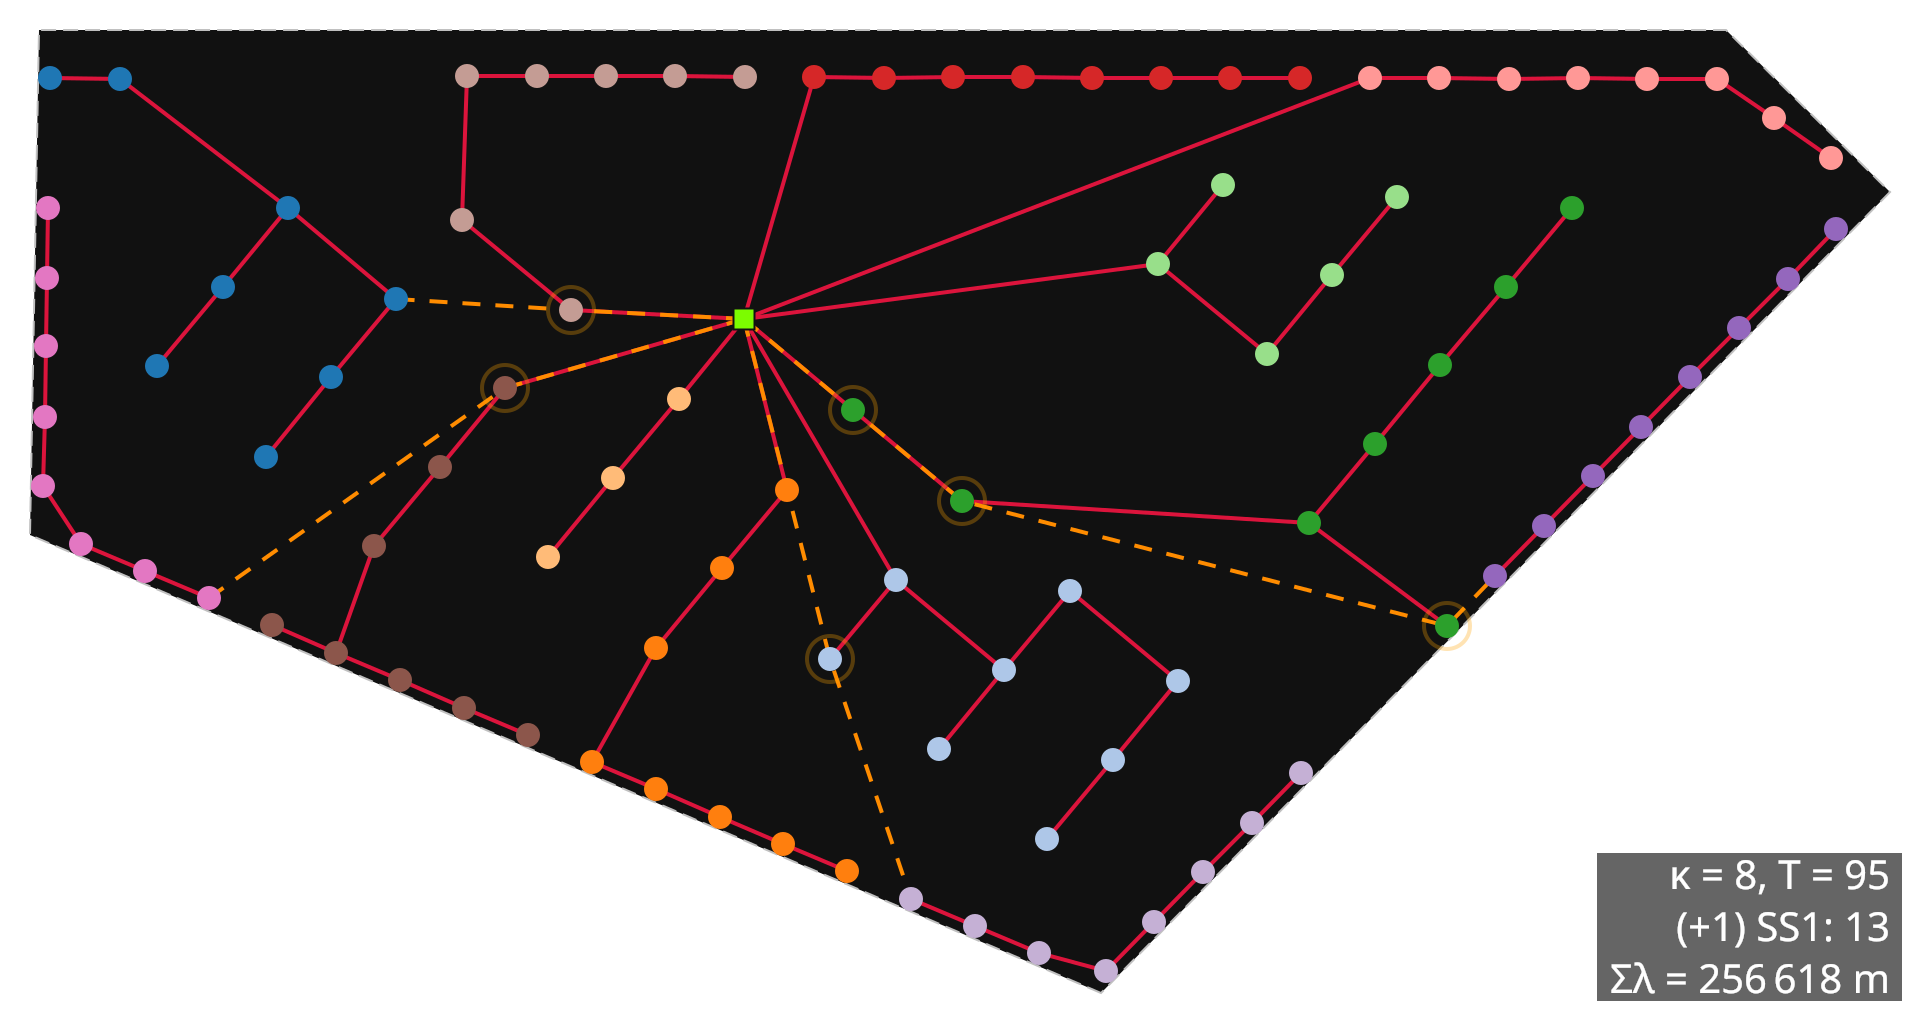

In [11]:
svgplot(G_pre)

### Quick (radial only, a second or two)

In [12]:
from optiwindnet.baselines.hgs import hgs_cvrp
from optiwindnet.interarraylib import as_normalized

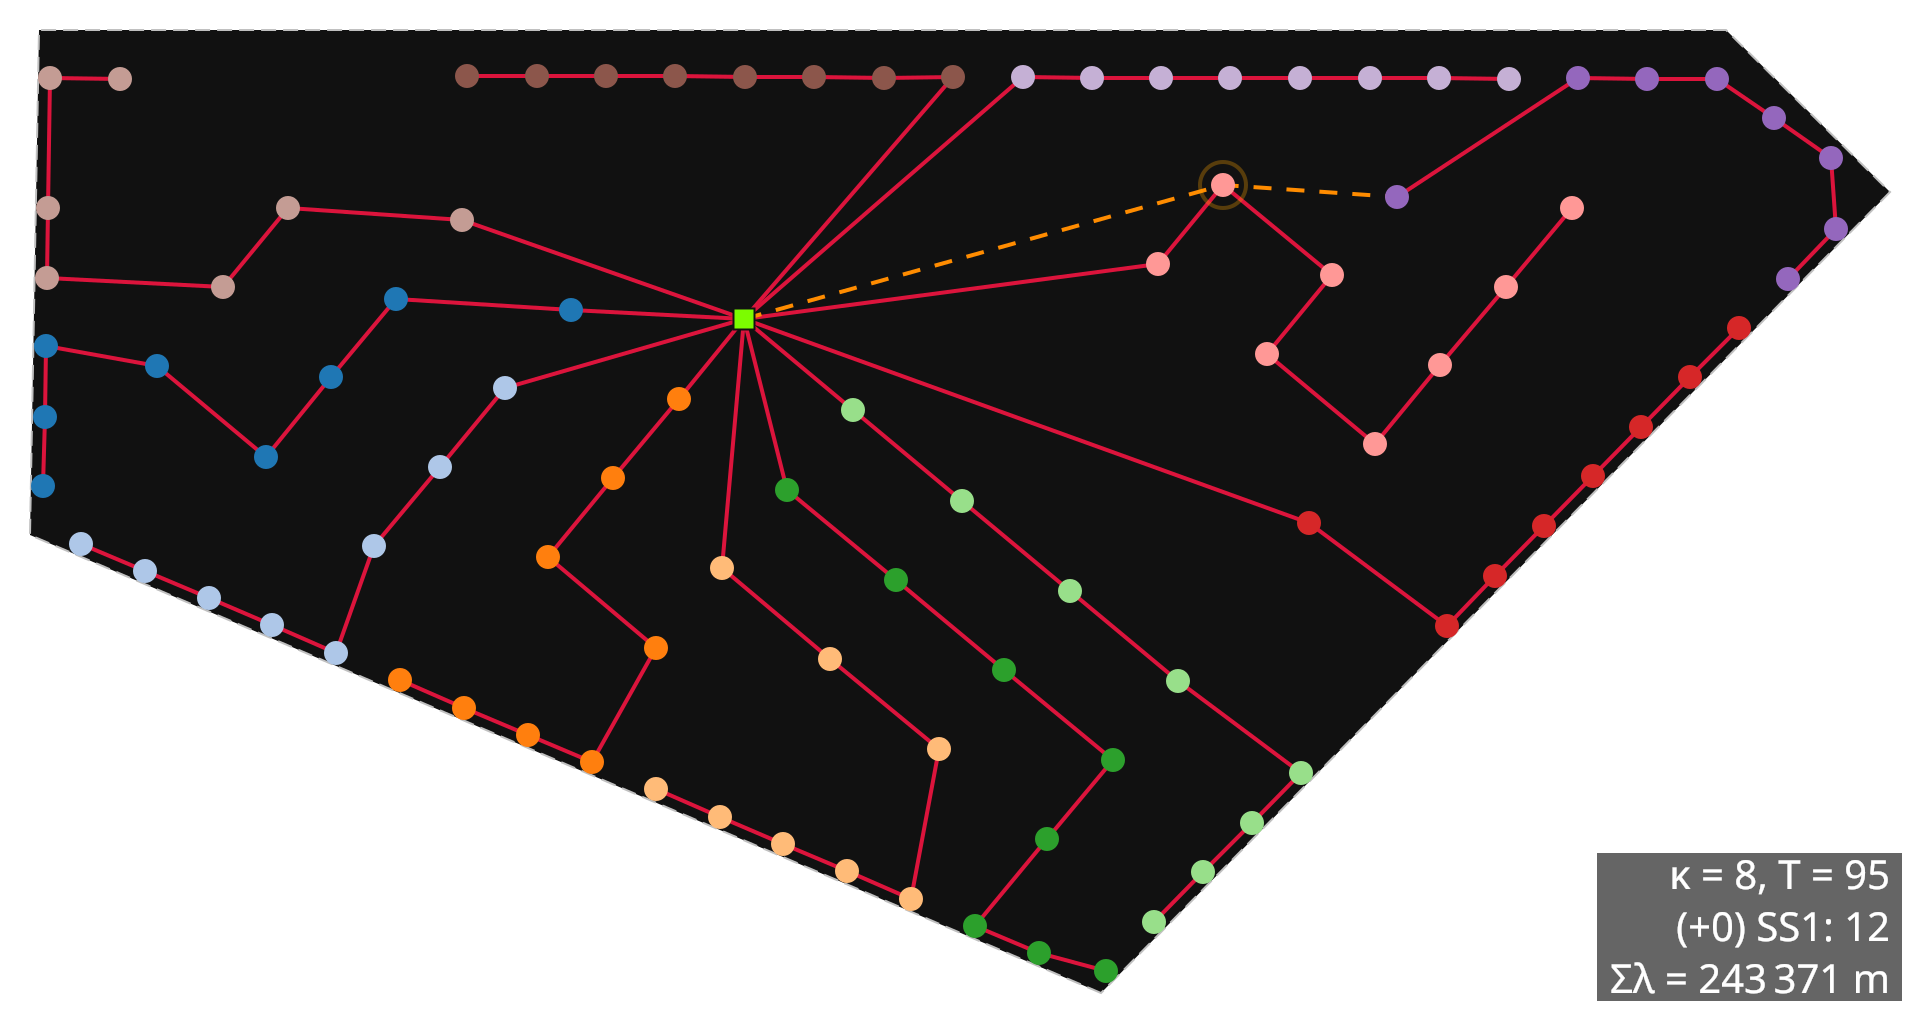

In [13]:
L = locations.doggerA
P, A = make_planar_embedding(L)
S_hgs = hgs_cvrp(as_normalized(A), capacity=8, time_limit=2)
G_tentative = G_from_S(S_hgs, A)
G_hgs = PathFinder(G_tentative, planar=P, A=A).create_detours()
svgplot(G_hgs)

### With quality assurance (a few minutes)

In [14]:
from optiwindnet.MILP import ModelOptions, solver_factory

In [15]:
solver = solver_factory('ortools.cp_sat')

In [16]:
ModelOptions.help()

topology in {"radial", "branched", "ringed"} default: branched
    Architecture of the subtrees in a solution.

feeder_route in {"straight", "segmented"} default: segmented
    If feeder routes must be ``'straight'`` or can be detoured (``'segmented'``).

feeder_limit in {"unlimited", "exactly", "specified", "minimum", "min_plus1", "min_plus2", "min_plus3"} default: unlimited
    Whether to limit the number of feeders. Both ``'specified'`` (an upper
    bound) and ``'exactly'`` (an exact count) require the additional kwarg
    ``'max_feeders'``. Option ``'balanced'`` is only enforceable if the feeder
    count is pinned to a single value, i.e. ``'minimum'`` or ``'exactly'``.

balanced [bool] default: False
    Whether to enforce balanced subtrees (subtree loads differ at most by one unit).

max_feeders [int] default: 0
    Number of feeders: the maximum if <feeder_limit = "specified">, the exact count if <feeder_limit = "exactly">



In [17]:
solver.set_problem(
    P,
    A,
    S_hgs.graph['capacity'],
    ModelOptions(
        topology='branched', feeder_route='segmented', feeder_limit='unlimited'
    ),
    warmstart=S_hgs,
)

In [18]:
# required to get the log inside the notebook (goes only to console otherwise)
solver.log_callback = print

solver.solve(
    time_limit=40,
    mip_gap=0.005,
    verbose=True,
)

IntegerBoundsPreprocessor                              2613 rows, 1690 columns, 9531 entries with magnitude in [1.000000e+00, 8.000000e+00]
BoundPropagationPreprocessor                           2613 rows, 1690 columns, 9531 entries with magnitude in [1.000000e+00, 8.000000e+00]
ImpliedIntegerPreprocessor                             2613 rows, 1690 columns, 9531 entries with magnitude in [1.000000e+00, 8.000000e+00]
IntegerBoundsPreprocessor                              2613 rows, 1690 columns, 9531 entries with magnitude in [1.000000e+00, 8.000000e+00]
ReduceCostOverExclusiveOrConstraintPreprocessor        2613 rows, 1690 columns, 9531 entries with magnitude in [1.000000e+00, 8.000000e+00]

Scaling to pure integer problem.
Num integers: 845/1690 (implied: 0 in_inequalities: 0 max_scaling: 0) [MIP] 
Maximum constraint coefficient relative error: 0
Maximum constraint worst-case activity error: 0
Constraint scaling factor range: [1, 1]

Starting CP-SAT solver v9.15.6755
Parameters: max_t

SolutionInfo(runtime=40.085153, bound=229721.09639212402, objective=240715.159901454, relgap=0.0456725015318139, termination='FEASIBLE')

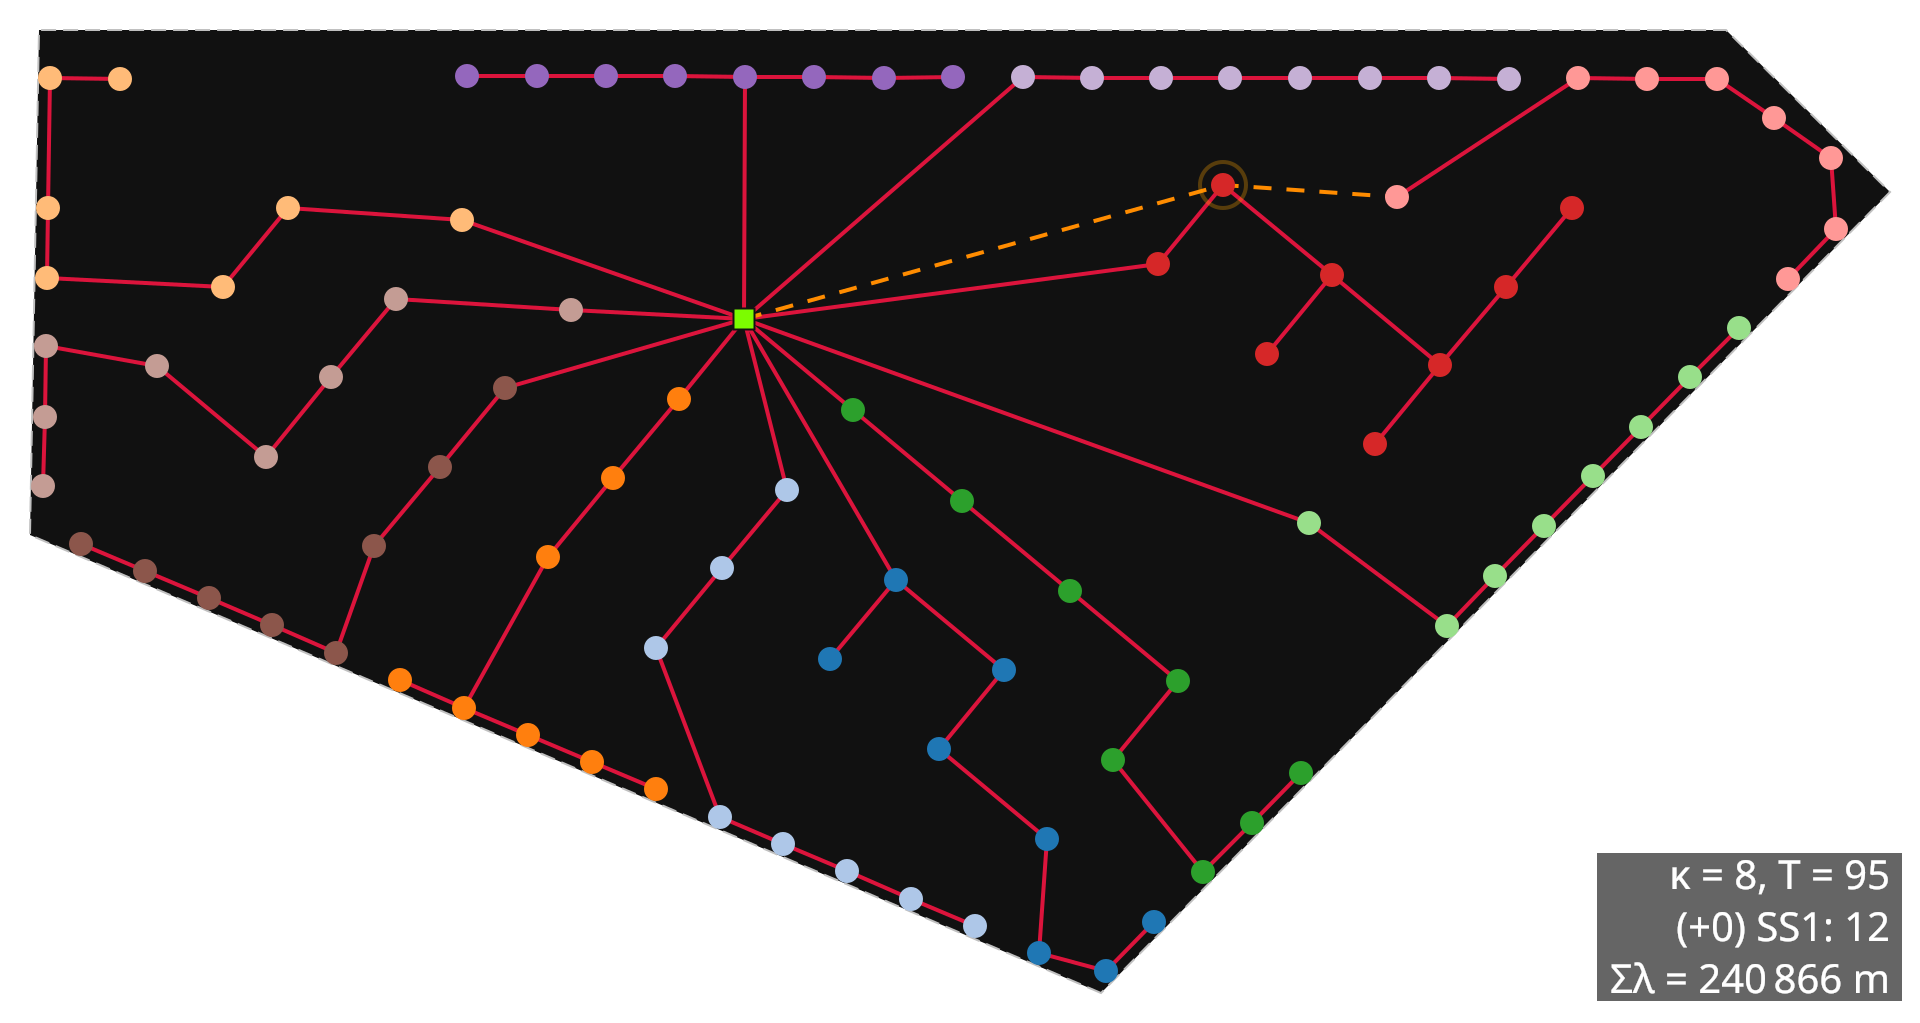

In [19]:
S, G = solver.get_solution()
svgplot(G)